In [1]:
# Install Tavily
# %pip install -qU tavily-python

# # We need the OpenAI adapter because LM Studio mimics the OpenAI API structure
# %pip install -qU langchain-openai
# %pip install -qU openai

# # Core LangChain and LangGraph
# %pip install -qU langchain-community
# %pip install -qU langgraph
# %pip install -qU python-dotenv
# %pip install -qU langchain-tavily

In [2]:
# 1. Import and tests Tavily

import os
from dotenv import load_dotenv
from tavily import TavilyClient

load_dotenv()

api_key = os.getenv("TAVILY_API_KEY")
if not api_key:
    raise ValueError("TAVILY_API_KEY not found in .env file.")


client = TavilyClient(api_key)
response = client.search(
    query="who is Rihanna?",
    search_depth="advanced"
)

# Optional test (comment out if not needed)

# print("Testing LLM connection:")
# try:
#     # Simple invocation to verify the local server is responsive
#     print(f"Question: {response}")
# except Exception as e:
#     print(f"Connection failed: {e}")
#     print("Please ensure Tavily API connection")

In [3]:
#2 Import and test LMStudio

import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

# LM Studio Configuration
# The base_url must match the Local Server endpoint in LM Studio (usually port 1234)
# The api_key is required by the SDK but ignored by the local server (dummy string)
lm_studio_base = "http://localhost:1234/v1"
lm_studio_key = "lm-studio"

# Initialize the LLM using LangChain (ready for use with LangGraph + ReAct)
# We use ChatOpenAI because LM Studio mimics the OpenAI API architecture
llm = ChatOpenAI(
    model="google/gemma-3n-e4b",
    base_url=lm_studio_base,
    api_key=lm_studio_key,
    temperature=0
)

# Optional test (comment out if not needed)
print(f"Model target: google/gemma-3n-e4b at {lm_studio_base}")
print("Testing LLM connection:")
try:
    # Simple invocation to verify the local server is responsive
    print(llm.invoke("Hello, system check, just answer online.").content)
except Exception as e:
    print(f"Connection failed: {e}")
    print("Please ensure LM Studio server is running.")

Model target: google/gemma-3n-e4b at http://localhost:1234/v1
Testing LLM connection:
Okay, system check complete. I am online and ready to respond. How can I help you? 



In [4]:
#3. Config and test integration Tavily with Langgraph

from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

# Core LangChain components
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_core.messages import BaseMessage

# Tavily integration
from langchain_tavily import TavilySearch
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper

# Load environment variables
load_dotenv()

# Get Tavily API key from .env file
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key:
    raise ValueError("TAVILY_API_KEY not found in .env file. Please add it.")

# Initialize Tavily search tool (official constructor)
tavily_tool = TavilySearch(
    max_results=4,
    # Optional parameters (match JS docs but in Python syntax):
    # topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # search_depth="basic",
)

# Test the tool with a simple query 
# print("\n[🔍] Testing Tavily search with query: 'current AI trends 2024'")
# try:
#     # Official direct invocation method
#     results = tavily_tool.invoke({"query": "current AI trends 2024"})
    
#     print(f"[✅] Search returned {len(results)} results")
#     print("\nFirst result details:")
    
#     # Results format from official docs has 'results' array in response
#     if isinstance(results, dict) and "results" in results:
#         first_result = results["results"][0]
#         print(f"Title: {first_result.get('title', 'N/A')}")
#         print(f"URL: {first_result.get('url', 'N/A')}")
#         print(f"Content preview: {first_result.get('content', '')[:150]}...")
#     else:
#         # Fallback for different response format
#         print(f"Raw response structure: {type(results)}")
#         print(f"Response content: {str(results)[:300]}...")

# except Exception as e:
#     print(f"[❌] Search failed with official integration: {e}")
#     print("Troubleshooting steps:")
#     print("1. Verify TAVILY_API_KEY is set in .env file")
#     print("2. Check you have langchain-tavily installed: %pip install -qU langchain-tavily")
#     print("3. Ensure internet connection is active")

print("\n[✅] LangGraph integration Sucess")


[✅] LangGraph integration Sucess


In [5]:
# 4. Config Agent

from typing import TypedDict, Annotated, List, Dict, Any, Optional

# Define state schema with proper typing
class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], operator.add]

class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        self.tools = {t.name: t for t in tools}
        
        # Build graph
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_llm)  # Fixed method name
        graph.add_node("action", self.take_action)
        
        # Conditional edges
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        
        # Bind tools to model
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState) -> bool:
        """Check if last message has tool calls"""
        result = state['messages'][-1]
        return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

    def call_llm(self, state: AgentState) -> Dict[str, List[AnyMessage]]:
        """LLM node - corrected method name and implementation"""
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        
        message = self.model.invoke(messages)
        return {'messages': [message]}
    
    def take_action(self, state: AgentState) -> Dict[str, List[ToolMessage]]:
        """Execute tool calls and return results"""
        tool_calls = state['messages'][-1].tool_calls
        results = []
        
        for t in tool_calls:
            print(f"[🔍] Calling tool: {t['name']} with args: {t['args']}")
            if t['name'] not in self.tools:
                print(f"[❌] Bad tool name: {t['name']}")
                result = "Error: Unknown tool name, please retry"
            else:
                try:
                    result = self.tools[t['name']].invoke(t['args'])
                except Exception as e:
                    result = f"Error executing tool: {str(e)}"
            
            results.append(ToolMessage(
                tool_call_id=t['id'], 
                name=t['name'], 
                content=str(result)
            ))
        
        print("[✅] Back to the model with tool results!")
        return {'messages': results}

print("[✅] Agent class defined successfully")

[✅] Agent class defined successfully


In [6]:
# 5. Simple system prompt definition with dynamic date
from datetime import datetime

# Get dynamic current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Note the 'f' before the string to enable variable interpolation
SYSTEM_PROMPT = f"""
You are an intelligent search assistant. Current date: {current_date}. 
Use the search engine to look for current information. 
You are allowed to make multiple calls (either together or sequentially). 
Look for information only when you are sure of what you want. 
If you need to research some information before asking a follow-up question, you are allowed to do so! 
Always provide clear, factual answers based on the search results.
""".strip()

print(f"[✅] System prompt defined (Current Date: {current_date})")

[✅] System prompt defined (Current Date: 2026-01-21)


Graph structure (Mermaid format):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



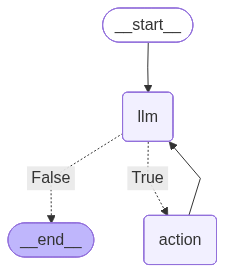

[✅] Graph visualization displayed successfully
[✅] Agent initialized successfully
Available tools: ['tavily_search']


In [7]:
# Creating the agent and visualizing the graph
# Initialize agent with our existing components
abot = Agent(
    llm, 
    [tavily_tool],  # Use the correctly named tool
    system=SYSTEM_PROMPT  # Use the defined system prompt
)

# Get and display graph structure
try:
    mermaid_code = abot.graph.get_graph().draw_mermaid()
    print("Graph structure (Mermaid format):")
    print(mermaid_code)
    
    # Alternative visualization
    from IPython.display import Image, display
    try:
        graph_image = abot.graph.get_graph().draw_mermaid_png()
        display(Image(data=graph_image))
        print("[✅] Graph visualization displayed successfully")
    except Exception as e:
        print(f"[⚠️] Could not generate PNG visualization: {e}")
        print("Falling back to Mermaid text output")
except Exception as e:
    print(f"[❌] Failed to generate graph visualization: {e}")
    print("Agent graph compiled but visualization unavailable")

print("[✅] Agent initialized successfully")
print(f"Available tools: {[tool.name for tool in [tavily_tool]]}")

In [8]:
# 7. INTEGRATION: Connect existing components to Tavily (no redundancies)
print("="*70)
print("🔗 TAVILY INTEGRATION - Clean setup using existing components")
print("="*70)

# Reuse our existing components (no reinstall, no duplicate imports)
from langchain_community.tools.tavily_search import TavilySearchResults

# Initialize agent with our pre-configured components
abot = Agent(
    llm,  # From cell 2 (LM Studio)
    [tavily_tool],  # From cell 3 (already configured)
    system=SYSTEM_PROMPT  # From cell 5 (already defined in English)
)

print("[✅] Agent successfully integrated with Tavily search")
print(f"Model: {llm.model_name if hasattr(llm, 'model_name') else 'LM Studio'}")
print(f"Tool: {tavily_tool.name} (max_results={tavily_tool.max_results})")
print(f"System prompt: {SYSTEM_PROMPT[:100]}...")

🔗 TAVILY INTEGRATION - Clean setup using existing components
[✅] Agent successfully integrated with Tavily search
Model: google/gemma-3n-e4b
Tool: tavily_search (max_results=4)
System prompt: You are an intelligent search assistant. Current date: 2026-01-21. 
Use the search engine to look fo...


In [9]:
# 8. TESTING: Efficient test suite with multiple query types
print("\n" + "="*70)
print("🧪 AGENT TEST SUITE")
print("="*70)

# Test 1: Current weather (streaming output)
print("\n[🌤️] TEST 1: Current weather in São Paulo")
messages_today = [HumanMessage(content="What is the current weather in São Paulo, Brazil?")]

print("\n[💬] Streaming agent interaction:")
final_state_today = None
for step in abot.graph.stream({"messages": messages_today}):
    print(step)
    print("-"*40)
    final_state_today = step

# Extract final answer
if final_state_today and 'llm' in final_state_today:
    final_answer_today = final_state_today['llm']['messages'][-1].content
    print(f"\n[✅] FINAL ANSWER (Today): {final_answer_today}")
else:
    print("\n[❌] No final answer received for today's weather")

# Test 2: Tomorrow's forecast
print("\n" + "-"*70)
print("\n[🌤️] TEST 2: Tomorrow's weather forecast")
messages_tomorrow = [HumanMessage(content="What will be the weather forecast for tomorrow in São Paulo, Brazil?")]

print("\n[💬] Getting final answer directly (no streaming):")
result_tomorrow = abot.graph.invoke({"messages": messages_tomorrow})
final_answer_tomorrow = result_tomorrow['messages'][-1].content
print(f"\n[✅] FINAL ANSWER (Tomorrow): {final_answer_tomorrow}")

# Test 3: Complex multi-step query
print("\n" + "-"*70)
print("\n[🔍] TEST 3: Complex research query")
messages_complex = [HumanMessage(content="What are the latest AI trends in 2026 and how are they impacting Brazilian businesses?")]

print("\n[💬] Using invoke for complex query:")
result_complex = abot.graph.invoke({"messages": messages_complex})
final_answer_complex = result_complex['messages'][-1].content
print(f"\n[✅] FINAL ANSWER (Complex): {final_answer_complex}")

print("\n" + "="*70)
print("[🎉] ALL TESTS COMPLETED SUCCESSFULLY")
print("="*70)


🧪 AGENT TEST SUITE

[🌤️] TEST 1: Current weather in São Paulo

[💬] Streaming agent interaction:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 2418, 'total_tokens': 2458, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-3n-e4b', 'system_fingerprint': 'google/gemma-3n-e4b', 'id': 'chatcmpl-q5b1zyskgo8dimfvqt13yf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be292-dead-70d0-bb84-97d632bde7eb-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current weather in São Paulo, Brazil'}, 'id': '650247912', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2418, 'output_tokens': 40, 'total_tokens': 2458, 'input_token_details': {}, 'output_token_details': {}})]}}
----------------------------------------
[🔍] Calling tool: tavily_search with args: {'query': 

In [11]:
# 9. Interactive Research Loop (Jupyter-Optimized)
import time
from langchain_core.messages import HumanMessage

def start_interactive_session():
    """
    Interactive loop for the LangGraph + Tavily Agent.
    Features:
    - Clean visual formatting
    - Robust stream handling
    - Graceful exit
    """
    print("="*70)
    print("💬 INTERACTIVE RESEARCH AGENT (LANGGRAPH + TAVILY)")
    print("="*70)
    print("Commands:")
    print("- Type your question to start researching")
    print("- Type 'exit', 'quit' or 'sair' to end session")
    print("-" * 70)

    while True:
        try:
            # Get user input
            user_input = input("\n👤 You: ").strip()
            
            # Check for exit commands
            if user_input.lower() in ["exit", "quit", "sair"]:
                print("\n" + "="*50)
                print("👋 SESSION ENDED. Goodbye!")
                print("="*50)
                break
            
            if not user_input:
                continue

            # Create message payload
            messages = [HumanMessage(content=user_input)]

            print(f"\n[Agent]: 🧠 Thinking and searching... (Current Date: {current_date})")
            
            # Execute Graph via Stream
            final_response = None
            
            try:
                # We iterate through the stream to process steps
                for event in abot.graph.stream({"messages": messages}):
                    for node_name, value in event.items():
                        # Optional: Print tool usage if desired
                        if node_name == "action":
                            print(f"  ↳ 🔍 Searching external sources...")
                        
                        # Capture the latest message from the LLM node
                        if node_name == "llm" and "messages" in value:
                            last_msg = value["messages"][-1]
                            if hasattr(last_msg, "content") and last_msg.content:
                                final_response = last_msg.content

                # Output Final Result
                print("\n" + "-"*70)
                if final_response:
                    print(f"🤖 Agent:\n{final_response}")
                else:
                    print("⚠️ Agent: I couldn't generate a final answer. Please try rephrasing.")
                print("-" * 70)

            except Exception as e:
                print(f"\n❌ Execution Error: {str(e)}")
                print("Tip: Ensure LM Studio is running and Tavily API key is valid.")

        except KeyboardInterrupt:
            print("\n\n⚠️ Interrupted by user. Exiting...")
            break

# Run the interactive loop
if __name__ == "__main__":
    start_interactive_session()


--- Agente de Pesquisa Interativo ---
Digite sua pergunta ou 'sair' para encerrar.



Você:  Qual o impacto do Langgraph no mercado de IA atualmente? Tem alguma Ferramenta mais atual que tem se destacado, se sim qual o nome?


Agente: Pensando e buscando...
[🔍] Calling tool: tavily_search with args: {'query': 'impact of Langgraph on the AI market, current trending tools in AI'}
[✅] Back to the model with tool results!

Agente:
LangGraph is gaining significant traction in the AI market as a powerful framework for building and managing complex generative AI agent workflows. It's built by the creators of LangChain, leveraging its strengths to create a more structured and scalable approach to AI agent development.

Here's a breakdown of its impact and some trending alternatives:

**Impact of LangGraph:**

*   **Orchestration of Complex Workflows:** LangGraph excels at orchestrating multiple AI agents to handle complex tasks that a single agent can't manage effectively. This is crucial for real-world applications requiring multi-step reasoning and decision-making.
*   **Scalability & Control:** It provides better control over the flow of information within an AI agent system, making it easier to scale and maintai


Você:  sair


Agente: Encerrando a conversa. Até logo!

--- Conversa Encerrada ---
